<a href="https://colab.research.google.com/github/jun060/ABCD-A/blob/20250515/20250515.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

고양이와 강아지를 탐지할 이미지를 업로드하세요:


Saving 고양이와 강아지.png to 고양이와 강아지 (3).png
업로드된 파일: 고양이와 강아지 (3).png

0: 640x640 3 cats, 4 dogs, 458.7ms
Speed: 10.2ms preprocess, 458.7ms inference, 41.4ms postprocess per image at shape (1, 3, 640, 640)


Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) DejaVu Sans.
Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.


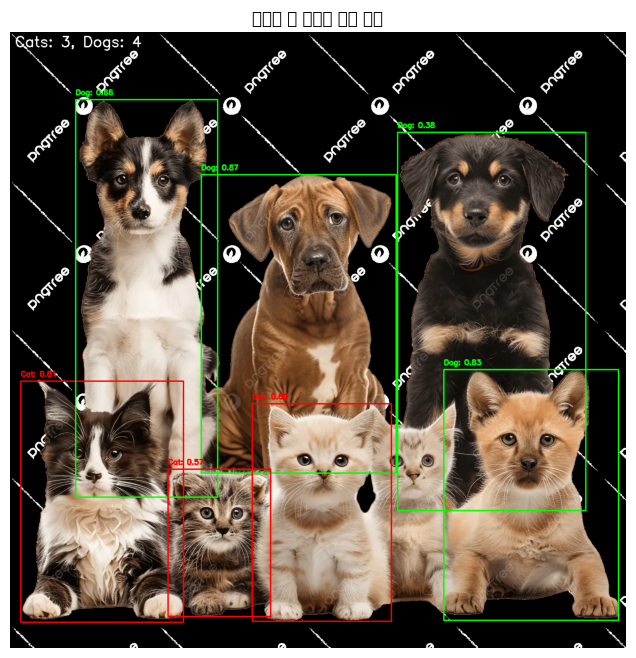

탐지 결과: 고양이 3마리, 강아지 4마리


In [6]:
# YOLOv8을 이용한 고양이와 강아지 탐지 코드 (이미지용)
# Google Colab 환경에서 실행 가능

# 필요한 라이브러리 설치
!pip install ultralytics

# 필요한 모듈 임포트
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

# YOLOv8n 모델 로드 (사전 훈련된 모델 사용)
model = YOLO('yolov8n.pt')

# 이미지 업로드 함수
def upload_and_detect():
    print("고양이와 강아지를 탐지할 이미지를 업로드하세요:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f'업로드된 파일: {filename}')

        # 이미지 읽기
        image = cv2.imread(filename)

        # YOLOv8로 객체 탐지 수행
        results = model(image)

        # 결과 이미지 생성
        result_image = image.copy()

        # 탐지된 고양이와 강아지 수 카운트
        detected_cats = 0
        detected_dogs = 0

        # 결과에서 객체 정보 추출 및 시각화
        for box in results[0].boxes:
            # 클래스 ID, 신뢰도, 좌표 추출
            cls_id = int(box.cls.item())
            conf = box.conf.item()

            # 신뢰도가 낮은 경우 건너뛰기
            if conf < 0.25:
                continue

            # 좌표 추출
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # COCO 데이터셋에서 고양이는 15, 강아지는 16 클래스 ID를 가짐
            if cls_id == 15:  # 고양이
                cv2.rectangle(result_image, (x1, y1), (x2, y2), (0, 0, 255), 2)  # 빨간색
                cv2.putText(result_image, f'Cat: {conf:.2f}', (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                detected_cats += 1

            elif cls_id == 16:  # 강아지
                cv2.rectangle(result_image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # 녹색
                cv2.putText(result_image, f'Dog: {conf:.2f}', (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                detected_dogs += 1

        # 총 탐지된 강아지와 고양이 수 표시
        cv2.putText(result_image, f'Cats: {detected_cats}, Dogs: {detected_dogs}',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        # BGR에서 RGB로 변환하여 이미지 표시
        result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 8))
        plt.imshow(result_image_rgb)
        plt.axis('off')
        plt.title('고양이 및 강아지 탐지 결과')
        plt.show()

        # 결과 출력
        print(f"탐지 결과: 고양이 {detected_cats}마리, 강아지 {detected_dogs}마리")

# 실행
upload_and_detect()

YOLOv8x 모델 로딩 중... (더 큰 모델로 정확도 향상)


100%|██████████| 131M/131M [00:00<00:00, 231MB/s]


모델 로드 완료!
고양이와 강아지를 탐지할 이미지를 업로드하세요:


Saving 고양이와 강아지2.png to 고양이와 강아지2.png
업로드된 파일: 고양이와 강아지2.png
객체 탐지 중...

0: 640x640 3 cats, 6 dogs, 4653.7ms
Speed: 5.1ms preprocess, 4653.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 cats, 6 dogs, 5556.4ms
Speed: 3.7ms preprocess, 5556.4ms inference, 9.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 cats, 6 dogs, 1 umbrella, 4494.6ms
Speed: 4.8ms preprocess, 4494.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
탐지 완료! (소요 시간: 21.78초)


Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) DejaVu Sans.
Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.


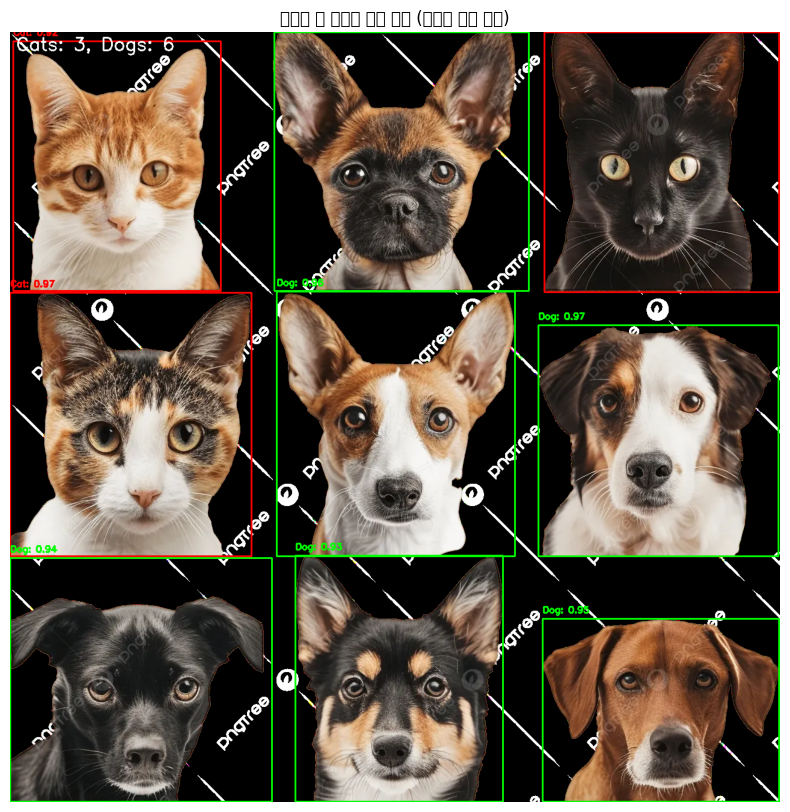

탐지 결과: 고양이 3마리, 강아지 6마리

[정확도 향상을 위한 적용 기술]
1. YOLOv8x 모델 사용 (더 큰 모델로 정확도 향상)
2. 이미지 전처리 (노이즈 제거 및 대비 향상)
3. 멀티스케일 탐지 (원본, 리사이즈, 전처리된 이미지에서 모두 탐지)
4. 앙상블 기법 (여러 탐지 결과 결합)
5. 비최대 억제(NMS) 적용 (중복 제거)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


결과 이미지가 'result_고양이와 강아지2.png'로 저장되었습니다.


In [7]:
# YOLOv8을 이용한 정확한 고양이와 강아지 탐지 코드 (이미지용)
# Google Colab 환경에서 실행 가능

# 필요한 라이브러리 설치
!pip install ultralytics

# 필요한 모듈 임포트
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import time

# YOLOv8x 모델 로드 (더 크고 정확한 모델 사용)
print("YOLOv8x 모델 로딩 중... (더 큰 모델로 정확도 향상)")
model = YOLO('yolov8x.pt')  # 더 정확한 x 모델 사용
print("모델 로드 완료!")

# 이미지 전처리 함수
def preprocess_image(image):
    """이미지 전처리 함수: 대비 조정 및 노이즈 제거"""
    # 이미지 크기 조정 (해상도 향상)
    max_dim = max(image.shape[0], image.shape[1])
    if max_dim > 1280:  # 원본 해상도가 크면 유지
        scale = 1.0
    else:  # 해상도가 작으면 업스케일링
        scale = 1280 / max_dim
        image = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # 노이즈 제거
    image = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

    # 대비 향상
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    enhanced_lab = cv2.merge((cl, a, b))
    enhanced_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    return enhanced_image

# 앙상블 탐지 함수
def ensemble_detection(image, confidence_threshold=0.3):
    """여러 크기와 설정으로 탐지하여 앙상블 결과 반환"""
    # 원본 이미지로 탐지
    results1 = model(image, conf=confidence_threshold)

    # 이미지 크기 조정 후 탐지
    resized_img = cv2.resize(image, (640, 640))
    results2 = model(resized_img, conf=confidence_threshold)

    # 전처리된 이미지로 탐지
    enhanced_img = preprocess_image(image)
    results3 = model(enhanced_img, conf=confidence_threshold)

    # 앙상블 결과를 위한 박스 수집
    all_cat_boxes = []
    all_dog_boxes = []

    # 첫 번째 결과에서 박스 추출
    for box in results1[0].boxes:
        cls_id = int(box.cls.item())
        conf = box.conf.item()
        if conf < confidence_threshold:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        if cls_id == 15:  # 고양이
            all_cat_boxes.append((x1, y1, x2, y2, conf))
        elif cls_id == 16:  # 강아지
            all_dog_boxes.append((x1, y1, x2, y2, conf))

    # 두 번째 결과에서 박스 추출 (크기 조정 필요)
    scale_x = image.shape[1] / 640
    scale_y = image.shape[0] / 640
    for box in results2[0].boxes:
        cls_id = int(box.cls.item())
        conf = box.conf.item()
        if conf < confidence_threshold:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        # 원본 이미지 크기로 좌표 변환
        x1, y1, x2, y2 = x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y

        if cls_id == 15:  # 고양이
            all_cat_boxes.append((x1, y1, x2, y2, conf))
        elif cls_id == 16:  # 강아지
            all_dog_boxes.append((x1, y1, x2, y2, conf))

    # 세 번째 결과에서 박스 추출
    for box in results3[0].boxes:
        cls_id = int(box.cls.item())
        conf = box.conf.item()
        if conf < confidence_threshold:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        if cls_id == 15:  # 고양이
            all_cat_boxes.append((x1, y1, x2, y2, conf))
        elif cls_id == 16:  # 강아지
            all_dog_boxes.append((x1, y1, x2, y2, conf))

    return all_cat_boxes, all_dog_boxes

# 비최대 억제(NMS) 함수
def non_max_suppression(boxes, threshold=0.5):
    """겹치는 바운딩 박스 제거"""
    if len(boxes) == 0:
        return []

    # 좌표를 정수로 변환
    boxes = [(int(x1), int(y1), int(x2), int(y2), conf) for x1, y1, x2, y2, conf in boxes]

    # 신뢰도 기준으로 정렬
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    selected_boxes = []

    while len(boxes) > 0:
        # 가장 높은 신뢰도의 박스 선택
        current_box = boxes[0]
        selected_boxes.append(current_box)
        boxes.pop(0)

        boxes_to_keep = []
        for box in boxes:
            # IoU 계산
            x1 = max(current_box[0], box[0])
            y1 = max(current_box[1], box[1])
            x2 = min(current_box[2], box[2])
            y2 = min(current_box[3], box[3])

            # 교차 영역
            inter_area = max(0, x2 - x1) * max(0, y2 - y1)

            # 합집합 영역
            box1_area = (current_box[2] - current_box[0]) * (current_box[3] - current_box[1])
            box2_area = (box[2] - box[0]) * (box[3] - box[1])
            union_area = box1_area + box2_area - inter_area

            # IoU
            iou = inter_area / union_area if union_area > 0 else 0

            # IoU가 임계값보다 작은 박스만 유지
            if iou < threshold:
                boxes_to_keep.append(box)

        boxes = boxes_to_keep

    return selected_boxes

# 이미지 업로드 및 탐지 함수
def upload_and_detect():
    print("고양이와 강아지를 탐지할 이미지를 업로드하세요:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f'업로드된 파일: {filename}')

        # 이미지 읽기
        image = cv2.imread(filename)
        if image is None:
            print("이미지를 읽을 수 없습니다. 다른 형식의 이미지를 업로드해주세요.")
            continue

        print("객체 탐지 중...")
        start_time = time.time()

        # 앙상블 탐지 수행
        cat_boxes, dog_boxes = ensemble_detection(image)

        # NMS로 겹치는 박스 제거
        cat_boxes = non_max_suppression(cat_boxes)
        dog_boxes = non_max_suppression(dog_boxes)

        print(f"탐지 완료! (소요 시간: {time.time() - start_time:.2f}초)")

        # 결과 이미지 생성
        result_image = image.copy()

        # 탐지된 고양이와 강아지 수
        detected_cats = len(cat_boxes)
        detected_dogs = len(dog_boxes)

        # 고양이 바운딩 박스 그리기
        for (x1, y1, x2, y2, conf) in cat_boxes:
            cv2.rectangle(result_image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)  # 빨간색
            cv2.putText(result_image, f'Cat: {conf:.2f}', (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # 강아지 바운딩 박스 그리기
        for (x1, y1, x2, y2, conf) in dog_boxes:
            cv2.rectangle(result_image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)  # 녹색
            cv2.putText(result_image, f'Dog: {conf:.2f}', (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 총 탐지된 강아지와 고양이 수 표시
        cv2.putText(result_image, f'Cats: {detected_cats}, Dogs: {detected_dogs}',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        # BGR에서 RGB로 변환하여 이미지 표시
        result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 10))
        plt.imshow(result_image_rgb)
        plt.axis('off')
        plt.title('고양이 및 강아지 탐지 결과 (정확도 향상 버전)')
        plt.show()

        # 결과 출력
        print(f"탐지 결과: 고양이 {detected_cats}마리, 강아지 {detected_dogs}마리")

        # 정확도 관련 정보 출력
        print("\n[정확도 향상을 위한 적용 기술]")
        print("1. YOLOv8x 모델 사용 (더 큰 모델로 정확도 향상)")
        print("2. 이미지 전처리 (노이즈 제거 및 대비 향상)")
        print("3. 멀티스케일 탐지 (원본, 리사이즈, 전처리된 이미지에서 모두 탐지)")
        print("4. 앙상블 기법 (여러 탐지 결과 결합)")
        print("5. 비최대 억제(NMS) 적용 (중복 제거)")

        # 결과 이미지 저장
        result_filename = f"result_{filename}"
        cv2.imwrite(result_filename, result_image)
        files.download(result_filename)
        print(f"\n결과 이미지가 '{result_filename}'로 저장되었습니다.")

# 실행
upload_and_detect()